# MD-CLARA tutorial: pairfam activity and family trajectories (individuals)

This notebook applies **multidomain CLARA** to **people**, not cities: monthly life-course sequences from the German Family Panel (**pairfam**), pre-processed for teaching (Raab & Struffolino, 2022).

| Domain | Dataset | What it captures |
|--------|---------|------------------|
| **Activity** | `pairfam_activity_by_month` | Employment / activity status (8 states) |
| **Family** | `pairfam_family_by_month` | Partnership and parenthood (9 states) |

- **Unit of analysis:** one sequence = **one respondent** (`id`)
- **Time:** 264 **months**, ages 18–40 (columns `1` … `264`)
- **N:** 1,027 individuals (same `id` order in both files)

Dataset documentation (state definitions, covariates, processing):

- Activity: [pairfam-activity.md](https://github.com/Liang-Team/SequenzoWebsite/blob/main/docs/en/datasets/pairfam-activity.md) (Sequenzo docs)
- Family: [pairfam-family.md](https://github.com/Liang-Team/SequenzoWebsite/blob/main/docs/en/datasets/pairfam-family.md)

**Related tutorials**

- Patent cities (3 technology domains): [md_clara_patent_cities_tutorial.ipynb](md_clara_patent_cities_tutorial.ipynb)
- Compare IDCD / CAT / DAT on pairfam: [md_clara_pairfam_strategies.ipynb](md_clara_pairfam_strategies.ipynb)
- Multidomain concepts: [main_tutorial.ipynb](main_tutorial.ipynb)

## 1. Setup and load data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sequenzo import SequenceData, load_dataset
from sequenzo.multidomain.clara import (
    md_clara,
    plot_md_clara_quality,
    plot_md_clara_stability,
)
from sequenzo.visualization import plot_sequence_index

%matplotlib inline

df_activity = load_dataset("pairfam_activity_by_month")
df_family = load_dataset("pairfam_family_by_month")

print(f"Activity: {df_activity.shape}  |  Family: {df_family.shape}")
assert (df_activity["id"].values == df_family["id"].values).all(), (
    "Activity and family files must share the same individuals in the same row order."
)
print(f"Individuals: {len(df_activity)}")

Activity: (1027, 281)  |  Family: (1027, 281)
Individuals: 1027


## 2. Understand the two domains

### Activity states (numeric 1–8)

| Code | Abbrev. | Meaning |
|------|---------|--------|
| 1 | EDU | Education |
| 2 | MIL/CS | Military / civil service |
| 3 | PT | Part-time employment |
| 4 | FT | Full-time employment |
| 5 | SELF | Self-employed |
| 6 | PLEAVE | Parental leave |
| 7 | MARGINAL | Marginal employment |
| 8 | UNEMP | Unemployed |

### Family states (numeric 1–9)

| Code | Abbrev. | Meaning |
|------|---------|--------|
| 1 | S | Single, no child |
| 2 | LAT | Living apart together, no child |
| 3 | COH | Cohabiting, no child |
| 4 | MAR | Married, no child |
| 5 | Sc | Single, with child(ren) |
| 6 | LATc | LAT, with child(ren) |
| 7 | COHc | Cohabiting, with child(ren) |
| 8 | MARc1 | Married, 1 child |
| 9 | MARc2+ | Married, 2+ children |

Covariates (`sex`, `east`, `yeduc`, …) are identical in both files; we keep `weight40` (survey weight at age 40) for optional weighting.

In [2]:
COVARIATE_COLS = [
    "id", "weight40", "sex", "doby_gen", "dob", "ethni", "migstatus", "yeduc",
    "sat1i4", "sat5", "sat6", "highschool", "church", "biosib", "stepsib",
    "east", "famstructure18",
]
TIME_COLS = [c for c in df_activity.columns if c not in COVARIATE_COLS]
print(f"Monthly time points: {len(TIME_COLS)}  ({TIME_COLS[0]} … {TIME_COLS[-1]})")

person_meta = df_activity[COVARIATE_COLS].copy()
person_meta.head()

Monthly time points: 264  (1 … 264)


,id,weight40,sex,doby_gen,dob,ethni,migstatus,yeduc,sat1i4,sat5,sat6,highschool,church,biosib,stepsib,east,famstructure18
0,111000.0,0.343964,1,1971,855,1,1,11.5,5,7,5,0,0.0,1.0,0.0,1,1
1,2931000.0,1.767455,0,1973,881,5,3,10.5,5,5,5,0,1.0,1.0,0.0,0,0
2,3491000.0,0.726561,1,1971,857,1,1,18.0,10,-2,9,1,1.0,3.0,0.0,0,0
3,3902000.0,0.940405,0,1971,853,1,1,16.0,8,5,9,1,0.0,3.0,0.0,0,0
4,4814000.0,1.373152,0,1973,886,1,1,11.5,8,5,8,0,1.0,1.0,0.0,0,0


## 3. Build `SequenceData` for each domain

In [3]:
ACTIVITY_STATES = list(range(1, 9))
ACTIVITY_LABELS = [
    "Education",
    "Military/Civil service",
    "Part-time",
    "Full-time",
    "Self-employed",
    "Parental leave",
    "Marginal employment",
    "Unemployed",
]

FAMILY_STATES = list(range(1, 10))
FAMILY_LABELS = [
    "Single, no child",
    "LAT, no child",
    "Cohabiting, no child",
    "Married, no child",
    "Single, with child(ren)",
    "LAT, with child(ren)",
    "Cohabiting, with child(ren)",
    "Married, 1 child",
    "Married, 2+ children",
]

weights = df_activity["weight40"].values

seq_activity = SequenceData(
    df_activity,
    time=TIME_COLS,
    id_col="id",
    states=ACTIVITY_STATES,
    labels=ACTIVITY_LABELS,
    weights=weights,
)
seq_family = SequenceData(
    df_family,
    time=TIME_COLS,
    id_col="id",
    states=FAMILY_STATES,
    labels=FAMILY_LABELS,
    weights=weights,
)

domains = [seq_activity, seq_family]
print(seq_activity)
print(seq_family)

[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 1027
[>] Number of time points: 264
[>] Min/Max sequence length: 264 / 264
[>] States: [1, 2, 3, 4, 5, 6, 7, 8]
[>] Labels: ['Education', 'Military/Civil service', 'Part-time', 'Full-time', 'Self-employed', 'Parental leave', 'Marginal employment', 'Unemployed']
[>] Void: '%' (not in states (inactive); not observed in data) — out-of-window padding; SAMM/seqsamm drops subsequences containing void
[>] Weights: Provided (total weight=1244.245, mean=1.212, std=0.893)
[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 1027
[>] Number of time points: 264
[>] Min/Max sequence length: 264 / 264
[>] States: [1, 2, 3, 4, 5, 6, 7, 8, 9]


### Preview trajectories (first few individuals)

Sequences are long (264 months); plots show a subset. For a readable overview you can also aggregate to years in a separate analysis.

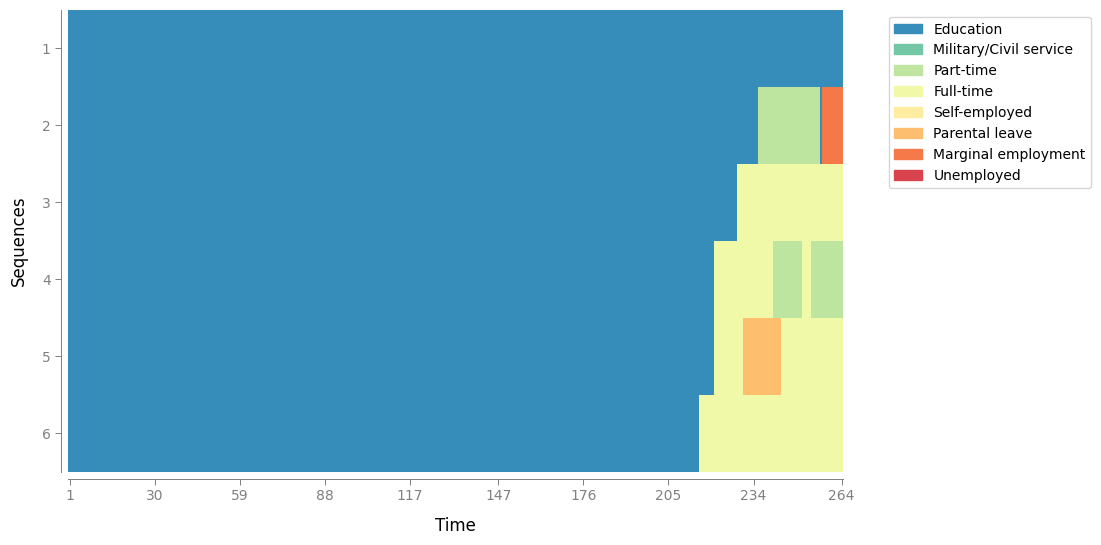

<Figure size 640x480 with 0 Axes>

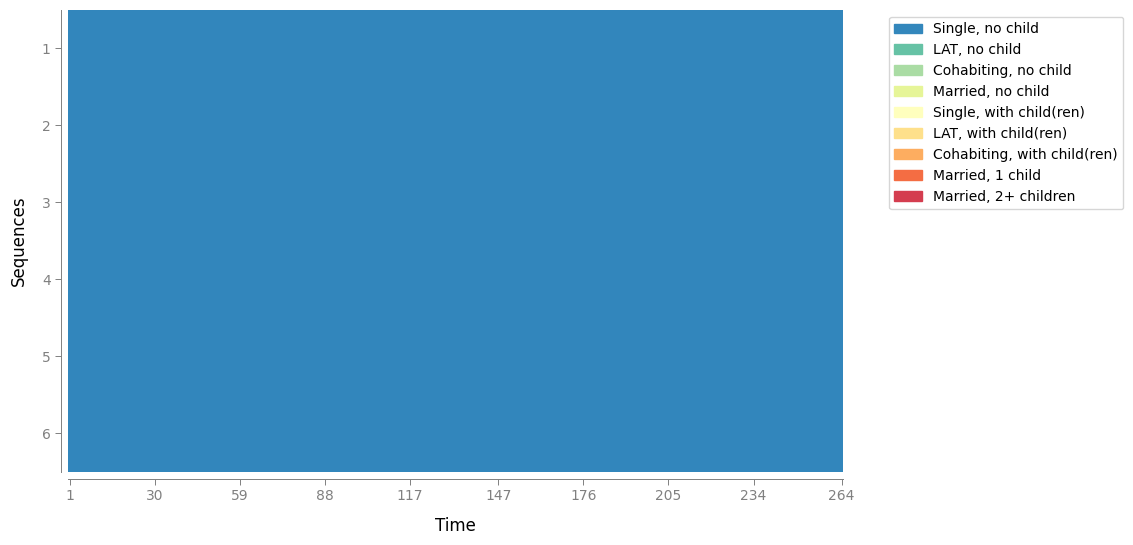

<Figure size 640x480 with 0 Axes>

In [4]:
plot_sequence_index(
    seq_activity,
    show_sequence_ids=False,
    sequence_selection="first_n",
    n_sequences=6,
)
plt.suptitle("Activity domain — sample individuals", y=1.02)
plt.show()

plot_sequence_index(
    seq_family,
    show_sequence_ids=False,
    sequence_selection="first_n",
    n_sequences=6,
)
plt.suptitle("Family domain — sample individuals", y=1.02)
plt.show()

## 4. Run MD-CLARA (IDCD)

We use strategy **`idcd`**: distances on **observed joint** activity–family states (e.g. full-time employment while married with one child). This is a natural default when work and family trajectories are linked.

**Note:** Monthly sequences with 264 time points are heavier than short patent panels. Start with moderate `R` and `sample_size`; increase for final analyses.

In [5]:
result = md_clara(
    domains,
    strategy="idcd",
    distance_params={
        "method": "OM",
        "sm": "CONSTANT",
        "indel": 1,
        "norm": "none",
    },
    R=20,
    sample_size=200,
    kvals=[2, 3, 4, 5, 6],
    criteria=("distance",),
    stability=True,
    random_state=42,
    n_jobs=-1,
    verbose=True,
)
result

[i] void='%' is not in 'states'; void_code unset. Add '%' to states if your data use void padding (TraMineR default '%').

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 937
[>] Number of time points: 264
[>] Min/Max sequence length: 264 / 264
[>] States: ['4+5', '4+1', '4+3', '4+9', '1+1', '4+7', '4+8', '1+3', '4+6', '3+9', '6+9', '1+5', '6+8', '7+9', '3+8', '4+2', '6+6', '2+1', '5+9', '3+6', '8+1', '2+3', '4+4', '3+5', '7+8', '1+7', '3+1', '8+9', '3+7', '5+8', '5+1', '1+8', '8+8', '3+2', '8+2', '1+6', '3+3', '8+5', '8+6', '5+5', '8+3', '2+5', '3+4', '5+3', '1+9', '8+7', '6+2', '5+6', '5+7', '7+3', '7+7', '7+1', '7+6', '6+4', '7+5', '6+7', '8+4', '5+2', '1+4', '5+4', '7+2', '2+6', '2+7', '1+2', '2+9', '6+5', '2+8', '7+4', '6+3', '2+2', '2+4', '6+1']
[>] Labels: ['4+5', '4+1', '4+3', '4+9', '1+1', '4+7', '4+8', '1+3', '4+6', '3+9', '6+9', '1+5', '6+8', '7+9', '3+8', '4+2', '6+6', '2+1', '5+9', '3+6', '8+1', '2+3', '4+4', '3+5', '7+8', '1+7', '3+1'

MDClaraResult(strategy='idcd', method='crisp', kvals=[2, 3, 4, 5, 6], best_by_k={2: {'medoids': array([940, 858]), 'medoids_agg': array([856, 784]), 'clustering': array([1., 2., 1., ..., 1., 1., 1.], shape=(1027,)), 'membership': None, 'evol_diss': array([322.92307692, 322.92307692, 322.92307692, 322.92307692,
       322.92307692, 322.92307692, 322.92307692, 322.92307692,
       322.92307692, 322.92307692, 322.92307692, 322.92307692,
       322.92307692, 322.92307692, 322.92307692, 322.92307692,
       322.92307692, 322.92307692, 322.92307692, 322.92307692]), 'iter_objective': [322.9230769230769, 328.54138266796497, 332.9328140214217, 330.45180136319374, 323.937682570594, 327.87925998052583, 324.17916260954235, 324.0915287244401, 335.5014605647517, 325.13145082765334, 326.47517039922104, 325.46835443037975, 327.69036027263877, 327.6884128529698, 327.63972736124634, 324.7400194741967, 323.5618305744888, 325.52677702044787, 333.9493670886076, 330.5413826679649], 'objective': 322.92307692

## 5. Results and interpretation

In [6]:
result.stats

,k,avg_dist,pbm,db,xb,ams,ari08,jc08,best_iter,criterion,R,sample_size,strategy
0,2,322.923077,0.353512,1.677761,0.840946,0.228580,1.0,1.0,0.0,distance,20,200,idcd
1,3,301.078870,0.250423,1.738029,0.912360,0.238404,1.0,1.0,12.0,distance,20,200,idcd
2,4,290.490750,0.163610,1.720565,0.937067,0.242105,1.0,1.0,15.0,distance,20,200,idcd
3,5,280.064265,0.104189,1.843218,1.166934,0.234290,1.0,1.0,12.0,distance,20,200,idcd
4,6,267.807205,0.101530,1.550506,0.858356,0.256723,1.0,1.0,0.0,distance,20,200,idcd


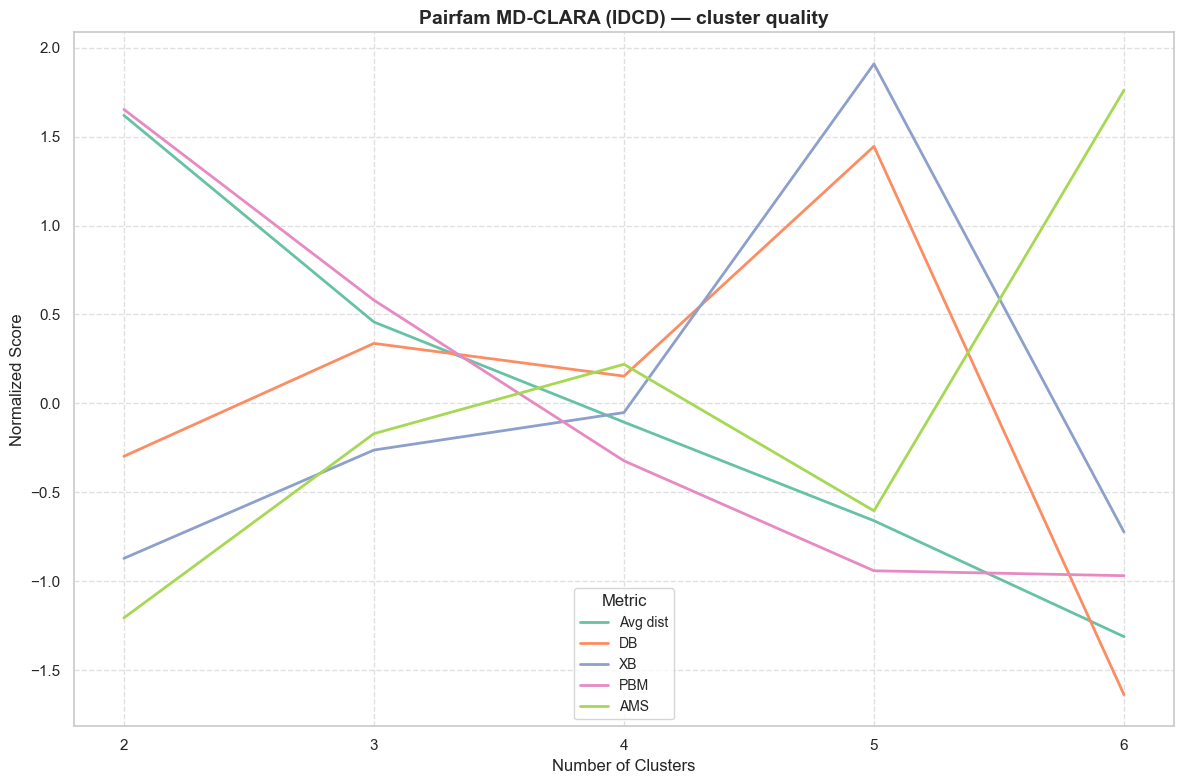

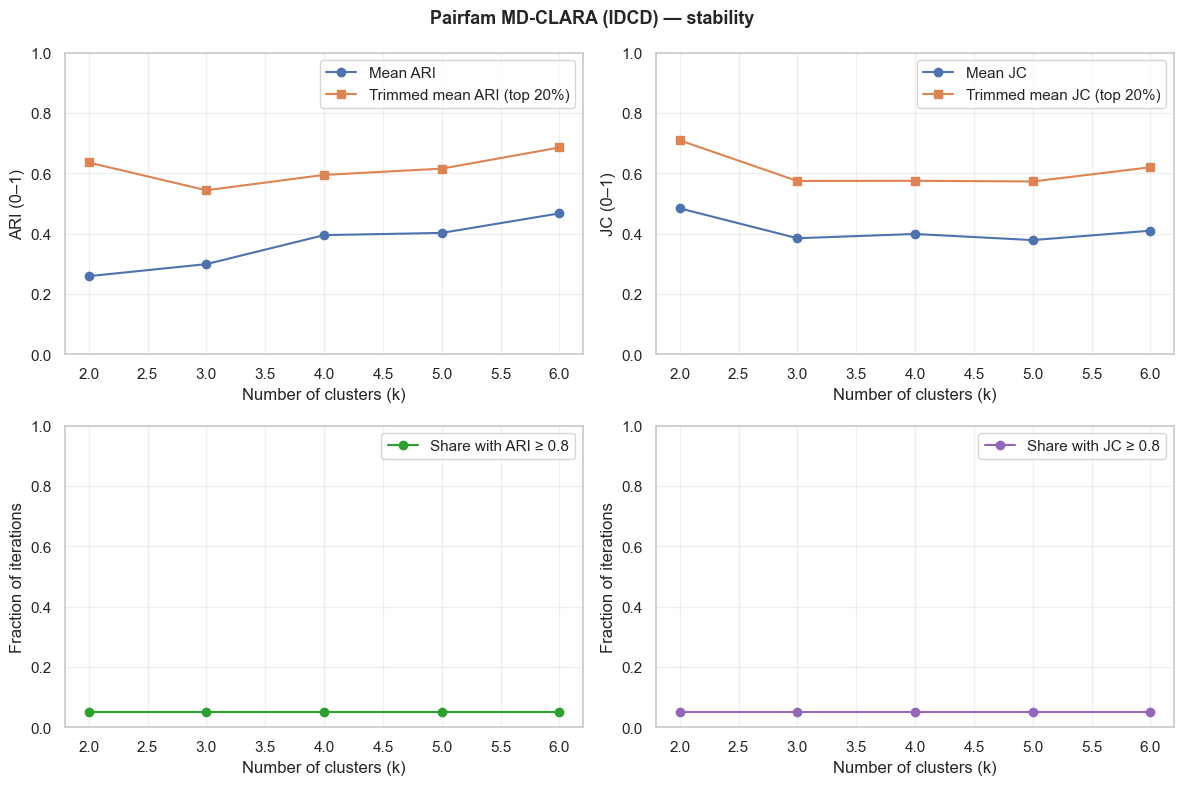

In [7]:
plot_md_clara_quality(result, title="Pairfam MD-CLARA (IDCD) — cluster quality")
plt.show()
plot_md_clara_stability(result, title="Pairfam MD-CLARA (IDCD) — stability")
plt.show()

In [8]:
K_CHOSEN = 4

labels = result.best_clustering(K_CHOSEN)
cluster_df = person_meta.copy()
cluster_df[f"cluster_k{K_CHOSEN}"] = labels

cluster_df.groupby(f"cluster_k{K_CHOSEN}")["sex"].mean()  # example: sex by cluster

cluster_k4
1.0    0.540146
2.0    0.983871
3.0    0.329609
4.0    0.344498
Name: sex, dtype: float64

In [9]:
cluster_df.groupby([f"cluster_k{K_CHOSEN}", "east"]).size().unstack(fill_value=0).head()

east,0,1
cluster_k4,,
1.0,171,103
2.0,138,48
3.0,200,158
4.0,120,89


## 6. Export and next steps

In [ ]:
from pathlib import Path

export = cluster_df.join(result.clustering)
out_path = Path("md_clara_pairfam_clusters.csv")
export.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")

- **Compare IDCD, CAT, and DAT** on the same individuals: [md_clara_pairfam_strategies.ipynb](md_clara_pairfam_strategies.ipynb)
- Relate clusters to `sex`, `east`, `yeduc`, etc., or use `plot_md_cluster_by_domain` for typology plots
- Year-level pairfam files (`*_by_year`) use **different IDs** and cannot be merged with these month-level data

Reference: Raab, M., & Struffolino, E. (2022). *Sequence analysis*. Sage.